In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import json
from typing import Iterable, Optional, List, Tuple, Dict, Any
import random
import math
import torch
import torch.nn.functional as F

ROOT = Path.cwd().parent                            # since notebook is in src
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    
DATA_PATH = ROOT / "data"
CORPUS_PATH = DATA_PATH / "hinditextdata.txt"
PREPROCESSED_PATH = DATA_PATH / "preprocessed_q2.txt"
BAGS_PATH = DATA_PATH / "ngram_bags.txt"

print("Exists:", DATA_PATH.exists(), DATA_PATH)
print("Corpus Exists:", CORPUS_PATH.exists(), CORPUS_PATH)

Exists: True c:\Users\rishi\02_dev\04_python\00_projects\NLP_Course\Assignment_1\data
Corpus Exists: True c:\Users\rishi\02_dev\04_python\00_projects\NLP_Course\Assignment_1\data\wmt-news-crawl-hi.txt


In [56]:
class NGramGenerator:
    def __init__(self, min_n: int = 3, max_n: int = 5, boundary_left: str = "<", boundary_right: str = ">"):
        if min_n <= 0 or max_n < min_n:
            raise ValueError(f"Invalid n-gram range: min_n={min_n}, max_n={max_n}")
        if not boundary_left or not boundary_right:
            raise ValueError("Boundary markers must be non-empty strings.")

        self.min_n, self.max_n = min_n, max_n
        self.boundary_left, self.boundary_right = boundary_left, boundary_right
        self.ngram2id, id2ngram = None, None

    def _add_boundary(self, token: str) -> str:
        return f"{self.boundary_left}{token}{self.boundary_right}"
    
    def extract_ngrams(self, token: str):
        token = self._add_boundary(token)
        ngrams = set()
        
        for n in range(self.min_n, self.max_n + 1):
            for i in range(len(token) - n + 1):
                ngram = token[i:i+n]
                ngrams.add(ngram)
        ngrams.add(token)                                       # special token - word itself
        
        return ngrams
    
    def ngram_vocab(self, preprocessed_path: str | Path, max_lines: int | None = None):
        """
        Build ngram2id and id2ngram from a preprocessed corpus file.
        ids assigned in ascending lexicographic order of n-gram strings.
        """
        preprocessed_path = Path(preprocessed_path)
        all_ngrams = set()

        num_lines = 0
        with preprocessed_path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                words = line.split()
                for w in words:
                    all_ngrams.update(self.extract_ngrams(w))

                num_lines += 1
                if max_lines is not None and num_lines >= max_lines:
                    break

        id2ngram = sorted(all_ngrams)                           # sort lexicographically
        ngram2id = {ng: i for i, ng in enumerate(id2ngram)}

        self.id2ngram = id2ngram
        self.ngram2id = ngram2id

        return ngram2id, id2ngram
    
    def word_to_ngram_ids(self, word: str):
        """
        Convert a word to sorted increasing n-gram ids using self.ngram2id.
        """
        if self.ngram2id is None:
            raise ValueError("ngram vocab not built yet. Call ngram_vocab() first.")

        ngrams = self.extract_ngrams(word)
        ids = []
        for ngram in ngrams:
            if ngram in self.ngram2id:
                ids.append(self.ngram2id[ngram])
        ids.sort()
        return ids
    
    def write_bags_file(self, preprocessed_path: str | Path, out_path: str | Path, max_lines: int | None = None):
        """
        Write space-separated word bags corresponding to each line.
        Each word bag: comma-separated n-gram IDs sorted increasing.
        """
        if self.ngram2id is None:
            raise ValueError("ngram vocab not built yet. Call ngram_vocab() first.")

        preprocessed_path = Path(preprocessed_path)
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)

        num_lines = 0
        with preprocessed_path.open("r", encoding="utf-8") as f_in, out_path.open("w", encoding="utf-8") as f_out:
            for line in f_in:
                line = line.strip()
                if not line:
                    f_out.write("\n")
                    continue

                words = line.split()
                word_bags = []
                for w in words:
                    ids = self.word_to_ngram_ids(w)
                    word_bags.append(",".join(map(str, ids)))                  # comma-separated IDs for this word

                f_out.write(" ".join(word_bags) + "\n")                        # space-separated bags for the line

                num_lines += 1
                if max_lines is not None and num_lines >= max_lines:
                    break

        return out_path
    
    def save_vocab(self, vocab_path: str | Path, config_path: str | Path | None = None):
        """
        Save n-gram vocabulary to file.
        
        - vocab_path: writes id2ngram, one n-gram per line, in ID order.
        - config_path: optional. writes generator config as JSON for safe reloading.
        """
        if self.id2ngram is None or self.ngram2id is None:
            raise ValueError("No vocab to save. Build vocab first using ngram_vocab().")

        vocab_path = Path(vocab_path)
        vocab_path.parent.mkdir(parents=True, exist_ok=True)

        with vocab_path.open("w", encoding="utf-8") as f:
            for ng in self.id2ngram:
                f.write(ng + "\n")

        if config_path is not None:
            config_path = Path(config_path)
            config_path.parent.mkdir(parents=True, exist_ok=True)
            cfg = {
                "min_n": self.min_n,
                "max_n": self.max_n,
                "boundary_left": self.boundary_left,
                "boundary_right": self.boundary_right,
            }
            with config_path.open("w", encoding="utf-8") as f:
                json.dump(cfg, f, ensure_ascii=False, indent=2)

        return vocab_path

    def load_vocab(self, vocab_path: str | Path, config_path: str | Path | None = None):
        """
        Load n-gram vocabulary from disk.
        
        - vocab_path: reads id2ngram (one per line) and reconstructs ngram2id.
        - config_path (optional): if provided, loads config and overwrites current settings.
        """
        vocab_path = Path(vocab_path)
        if not vocab_path.exists():
            raise FileNotFoundError(f"Vocab file not found: {vocab_path}")

        # Optional: load config first (so boundaries/min_n/max_n match what was used)
        if config_path is not None:
            config_path = Path(config_path)
            if not config_path.exists():
                raise FileNotFoundError(f"Config file not found: {config_path}")
            with config_path.open("r", encoding="utf-8") as f:
                cfg = json.load(f)

            self.min_n = int(cfg["min_n"])
            self.max_n = int(cfg["max_n"])
            self.boundary_left = str(cfg["boundary_left"])
            self.boundary_right = str(cfg["boundary_right"])

        with vocab_path.open("r", encoding="utf-8") as f:
            id2ngram = [line.rstrip("\n") for line in f]

        # Reconstruct mapping
        ngram2id = {ng: i for i, ng in enumerate(id2ngram)}

        self.id2ngram = id2ngram
        self.ngram2id = ngram2id

        return ngram2id, id2ngram

In [ ]:
class Trainer:
    def __init__(self, ngram_gen: NGramGenerator):
        self.ngram_gen = ngram_gen  
        self.word2id, self.id2word = None, None

        # negative sampling state
        self.neg_table, self.neg_table_size = None, None
        self.neg_rng, self.neg_exclude_ids = None, set()

        # subsampling state
        self.subsample_t, self.sub_rng = None, None
        self.subsample_probs = None                                     # dict: word -> drop_prob

    def word_vocab(
        self, word_counts: Counter, min_count: int = 1, max_vocab_size: int | None = None,
        special_tokens: list[str] | None = None, sort_by: str = "freq_then_lex",  # or "lex"
    ):
        """
        Build word vocab from a Counter of word frequencies.
        - special_tokens: list of tokens to add at the start of the vocab, like <UNK>.
        """
        if min_count <= 0:
            raise ValueError("min_count must be >= 1")

        special_tokens = special_tokens or []
        # Ensure uniqueness while preserving order
        seen = set()
        specials = []
        for t in special_tokens:
            if t not in seen:
                specials.append(t)
                seen.add(t)

        # Filter tokens by min_count and exclude special tokens if they appear in counts
        items = [(w, c) for w, c in word_counts.items() if c >= min_count and w not in seen]

        if sort_by == "freq_then_lex":
            # sort by (-freq, word) for determinism
            items.sort(key=lambda x: (-x[1], x[0]))
        elif sort_by == "lex":
            items.sort(key=lambda x: x[0])
        else:
            raise ValueError("sort_by must be 'freq_then_lex' or 'lex'")

        if max_vocab_size is not None:
            if max_vocab_size <= 0:
                raise ValueError("max_vocab_size must be positive")
            # max_vocab_size counts ALL tokens including specials
            remaining = max(0, max_vocab_size - len(specials))
            items = items[:remaining]

        id2word = specials + [w for w, _ in items]
        word2id = {w: i for i, w in enumerate(id2word)}

        self.id2word = id2word
        self.word2id = word2id

        # precompute word to ngram ids mapping
        self.word_ngram_ids = []
        for w in self.id2word:
            self.word_ngram_ids.append(self._word_to_ngram_ids(w))

        return word2id, id2word, items

    # ---------------------- Negative sampling ----------------------
    def build_negative_sampler(self, word_counts: Counter, power: float = 0.75, table_size: int = 1_000_000, seed: int = 42, exclude_tokens: list[str] | None = None,):
        """
        Builds negative sampling table
        Samples are drawn ~ count(word)^power over the current vocab.

        word_vocab() MUST BE CALLED FIRST BEFORE BUILDING THE NEGATIVE SAMPLER.
        """
        if self.word2id is None or self.id2word is None:
            raise ValueError("Build word vocab first before building negative sampler.")
        if power <= 0:
            raise ValueError("power must be positive")
        if table_size <= 0:
            raise ValueError("table_size must be positive")

        exclude_tokens = exclude_tokens or []
        exclude_ids = set()
        for tok in exclude_tokens:
            if tok in self.word2id:
                exclude_ids.add(self.word2id[tok])

        # Compute weights for vocab IDs (excluding chosen tokens)
        weights, ids = [], []
        total = 0.0
        for w, wid in self.word2id.items():
            if wid in exclude_ids:
                continue
            c = word_counts.get(w, 0)
            if c <= 0:
                continue
            wt = float(c) ** power
            weights.append(wt)
            ids.append(wid)
            total += wt

        if not ids:
            raise ValueError("No valid words to sample negatives from. Check counts/vocab/exclusions.")

        # Build cumulative distribution over ids, then fill table
        # We fill a table of size `table_size` with IDs according to the distribution.
        table = [0] * table_size
        cumulative = []
        running = 0.0
        for wt in weights:
            running += wt
            cumulative.append(running)

        # Fill table by sweeping through the cumulative mass
        j = 0
        for i in range(table_size):
            target = (i + 1) * total / table_size
            while cumulative[j] < target:
                j += 1
                if j >= len(cumulative):
                    j = len(cumulative) - 1
                    break
            table[i] = ids[j]

        self.neg_table = table
        self.neg_table_size = table_size
        self.neg_rng = random.Random(seed)
        self.neg_exclude_ids = exclude_ids

        return table                                                # optional

    def sample_negatives(self, k: int, avoid_id: int | None = None):
        """
        Sample k negative word IDs using the prebuilt table.
        If avoid_id is provided, tries not to return that ID.
        """
        if self.neg_table is None or self.neg_rng is None:
            raise ValueError("Call build_negative_sampler(...) before sampling negatives.")
        if k <= 0:
            return []

        negatives = []
        # simple rejection sampling to avoid a specific ID (and excluded IDs already avoided)
        while len(negatives) < k:
            wid = self.neg_table[self.neg_rng.randrange(self.neg_table_size)]
            if avoid_id is not None and wid == avoid_id:
                continue
            negatives.append(wid)
        return negatives
    
    # ---------------- Subsampling ----------------
    def build_subsampling(self, word_counts, total_tokens: int, t: float = 1e-5, seed: int = 42):
        """
        Precompute drop probabilities for subsampling frequent words.
        f(w) = count(w) / total_tokens. ie., relative frequency.
        """
        if total_tokens <= 0:
            raise ValueError("total_tokens must be positive")
        if t <= 0:
            raise ValueError("t must be positive")

        self.subsample_t = t
        self.sub_rng = random.Random(seed)

        drop_prob = {}
        for w, c in word_counts.items():
            f = c / total_tokens
            p_keep = math.sqrt(t / f)
            if p_keep > 1.0:
                p_keep = 1.0
            drop_prob[w] = 1.0 - p_keep

        self.subsample_probs = drop_prob
        return drop_prob

    def subsample_words(self, words: list[str]) -> list[str]:
        """
        Does subsampling. Requires build_subsampling() to have been called.
        """
        if self.subsample_probs is None or self.sub_rng is None:
            raise ValueError("Call build_subsampling() before subsample_words().")

        kept = []
        rng = self.sub_rng

        for w in words:
            dp = self.subsample_probs.get(w, 0.0)
            if rng.random() >= dp:
                kept.append(w)
        return kept

    # ---------------- Skip-gram pairs ----------------
    def generate_skipgram_pairs(self, tokenized_lines: Iterable[list[str]], context_window_size: int = 5, 
                                dynamic_window: bool = True, apply_subsampling: bool = True):
        """
        Yield (center_word, context_word) pairs from tokenized lines.
        - dynamic_window: if True, sample actual window radius r ~ Uniform(1..W) per center
        """
        if context_window_size <= 0:
            raise ValueError("context_window_size must be positive")

        rng = self.sub_rng if (apply_subsampling and self.sub_rng is not None) else random.Random(123)
        for words in tokenized_lines:
            if not words:
                continue

            if apply_subsampling:
                words = self.subsample_words(words)
                if len(words) < 2:
                    continue

            for i, center in enumerate(words):
                if dynamic_window: r = rng.randrange(1, context_window_size+1)
                else: r = context_window_size

                left = max(0, i - r)
                right = min(len(words), i + r + 1)
                for j in range(left, right):
                    if j == i:
                        continue
                    yield center, words[j]

    # ---------------- Training SGNS ----------------
    def init_model(self, num_ngrams: int, vocab_size: int, dim: int = 40,
                   lr: float = 0.05, seed: int = 42, device: str | None = None):                        # lr: learning rate
        """
        Create trainable parameters:
        - Z: ngram embeddings (num_ngrams x dim)
        - V: output/context embeddings (vocab_size x dim)
        """
        torch.manual_seed(seed)

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)

        self.dim = dim
        self.Z = torch.nn.Embedding(num_ngrams, dim).to(self.device)
        self.V = torch.nn.Embedding(vocab_size, dim).to(self.device)

        # initial values
        torch.nn.init.uniform_(self.Z.weight, a=-0.5/dim, b=0.5/dim)
        torch.nn.init.zeros_(self.V.weight)

        self.optimizer = torch.optim.SGD(list(self.Z.parameters()) + list(self.V.parameters()), lr=lr)
        self.lr = lr

        return self.Z, self.V
    
    def sgns_step(self, center_ngram_ids: list[int], pos_id: int, neg_ids: list[int]) -> float:         # skipgram negative sampling
        """
        One SGD update for skip-gram with negative sampling.
        Loss is the one used in word2vec neg sampling.
        """
        if not center_ngram_ids:
            return 0.0

        # tensors
        g = torch.tensor(center_ngram_ids, dtype=torch.long, device=self.device)     # (m,)
        pos = torch.tensor([pos_id], dtype=torch.long, device=self.device)         # (1,)
        neg = torch.tensor(neg_ids, dtype=torch.long, device=self.device)          # (k,)

        u = self.Z(g).sum(dim=0)                                                   # center vector u: sum of its ngram embeddings

        # positive score
        v_pos = self.V(pos).squeeze(0)                                             # (dim,)
        pos_score = torch.dot(u, v_pos)                                            # scalar

        # negative scores (k,)
        v_neg = self.V(neg)                                                       # (k, dim)
        neg_scores = v_neg @ u                                                    # (k,)

        loss = -F.logsigmoid(pos_score) - F.logsigmoid(-neg_scores).sum()

        # updating weights during backprop
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return float(loss.detach().cpu().item())
    
    def train_on_pair(self, center_word: str, context_word: str, k_neg: int = 5) -> float:
        """
        Convert (center_word, context_word) into IDs and run one sgns_step.
        """
        # center word as ngram IDs
        center_ngram_ids = self.ngram_gen.word_to_ngram_ids(center_word)

        # context word as wordID
        if context_word in self.word2id:
            pos_id = self.word2id[context_word]
        elif "<UNK>" in self.word2id:
            pos_id = self.word2id["<UNK>"]
        else:
            return 0.0                                                      # drop if not in vocab and no unk 

        neg_ids = self.sample_negatives(k=k_neg, avoid_id=pos_id)

        return self.sgns_step(center_ngram_ids, pos_id, neg_ids)
    
    def train(
        self, tokenized_lines_fn, window_size: int = 5, k_neg: int = 5, epochs: int = 1,
        dynamic_window: bool = False, apply_subsampling: bool = True, max_pairs: int | None = None, log_every: int = 50_000,
    ):
        """
        Train SGNS for given epochs. Streams over lines, generates skipgram pairs.
        """
        epoch_avg_losses = []
        for ep in range(1, epochs + 1):
            tokenized_lines = tokenized_lines_fn()
            epoch_running_loss = 0.0
            epoch_running_n = 0

            running_loss = 0.0
            running_n = 0
            step = 0

            skipgram_pairs = self.generate_skipgram_pairs(tokenized_lines=tokenized_lines, context_window_size=window_size, dynamic_window=dynamic_window, apply_subsampling=apply_subsampling)
            for center_word, context_word in skipgram_pairs:
                loss = self.train_on_pair(center_word, context_word, k_neg=k_neg)
                loss_val = float(loss)

                epoch_running_loss += loss_val
                epoch_running_n += 1

                running_loss += loss_val
                running_n += 1
                step += 1

                if log_every and step % log_every == 0:
                    print(f"[epoch {ep}] step={step:,} avg_loss={running_loss / running_n:.4f}")
                    running_loss = 0.0
                    running_n = 0

                if max_pairs is not None and step >= max_pairs:
                    break

            epoch_loss = epoch_running_loss / max(epoch_running_n, 1)
            epoch_avg_losses.append(epoch_loss)
            print(f"[epoch {ep}] epoch_avg_loss={epoch_loss:.4f}")

        return epoch_avg_losses

    # Inference: get word vectors and nearest neighbors
    def _word_to_ngram_ids(self, word: str) -> List[int]:
        """
        Returns list of ngram IDs for the word using self.ngram_gen.extract_ngrams.
        Skips ngrams that aren't in vocab.
        """
        ngrams = self.ngram_gen.extract_ngrams(word)
        ids = [self.ngram_gen.ngram2id[g] for g in ngrams if g in self.ngram_gen.ngram2id]
        return ids

    @torch.no_grad()
    def get_word_vector(self, word: str, normalize: bool = False) -> Optional[torch.Tensor]:
        """
        word vector: sum of subword embeddings from Z.
        Works for OOV if at least some ngrams exist in vocab.
        Returns a 1D tensor of shape (dim,).
        """
        ids = self._word_to_ngram_ids(word)
        if len(ids) == 0:
            return None

        device = self.Z.weight.device
        ids_t = torch.tensor(ids, dtype=torch.long, device=device)
        vec = self.Z(ids_t).sum(dim=0)  # (dim,)

        if normalize:
            vec = F.normalize(vec, dim=0)
        return vec

    @torch.no_grad()
    def _build_all_word_vectors(self, normalize: bool = True) -> torch.Tensor:
        """
        Build matrix of word vectors for every in-vocab word in self.id2word.
        Uses cached word->ngramIDs if available, else computes on the fly.
        Returns shape (V, dim).
        """
        device = self.Z.weight.device
        V = len(self.id2word)
        dim = self.Z.weight.shape[1]
        W = torch.zeros((V, dim), device=device)

        # SPEEDUP: if self.word_ngram_ids[word_id] is precomputed during word_vocab()
        if hasattr(self, "word_ngram_ids") and self.word_ngram_ids is not None:
            for wid in range(V):
                ids = self.word_ngram_ids[wid]
                if not ids:
                    continue
                ids_t = torch.tensor(ids, dtype=torch.long, device=device)
                W[wid] = self.Z(ids_t).sum(dim=0)
        else:
            for wid, w in enumerate(self.id2word):
                ids = self._word_to_ngram_ids(w)
                if not ids:
                    continue
                ids_t = torch.tensor(ids, dtype=torch.long, device=device)
                W[wid] = self.Z(ids_t).sum(dim=0)

        if normalize:
            W = F.normalize(W, dim=1)
        return W

    @torch.no_grad()
    def nearest_neighbors(self, query_word: str, k: int = 10, exclude_self: bool = True, restrict_to_top_vocab: Optional[int] = None) -> List[Tuple[str, float]]:
        """
        Cosine NN over in-vocab words using fastText word vectors.
        restrict_to_top_vocab: if set, only compares against first N words in id2word
        """
        q = self.get_word_vector(query_word, normalize=True)
        if q is None:
            return []

        W = self._build_all_word_vectors(normalize=True)
        if restrict_to_top_vocab is not None:
            W = W[:restrict_to_top_vocab]

        sims = W @ q  # (V,)
        sims = sims.clone()

        if exclude_self and query_word in self.word2id:
            wid = self.word2id[query_word]
            if wid < sims.shape[0]:
                sims[wid] = -1e9

        topk = min(k, sims.shape[0])
        vals, idx = torch.topk(sims, k=topk)

        out = []
        for score, wid in zip(vals.tolist(), idx.tolist()):
            out.append((self.id2word[wid], float(score)))
        return out
    
    # To save and load model params, vocab, etc
    def _metadata_dict(self) -> Dict[str, Any]:
        return {
            "dim": int(self.Z.weight.shape[1]),
            "min_n": getattr(self.ngram_gen, "min_n", None),
            "max_n": getattr(self.ngram_gen, "max_n", None),
            "window_size": getattr(self, "window_size", None),
            "k_neg": getattr(self, "k_neg", None),
            "subsampling_t": getattr(self, "t", None),
            "dynamic_window": getattr(self, "dynamic_window", None),
            "apply_subsampling": getattr(self, "apply_subsampling", None),
        }

    def save(self, path: str):
        """
        Saves:
        - Z and V weights
        - word vocab and ngram vocab
        - hyperparams/metadata
        """
        pkg = {
            "Z": self.Z.state_dict(),
            "V": self.V.state_dict(),
            "word2id": self.word2id,
            "id2word": self.id2word,
            "ngram2id": self.ngram_gen.ngram2id,
            "id2ngram": self.ngram_gen.id2ngram,
            "metadata": self._metadata_dict(),
        }
        
        if hasattr(self, "word_ngram_ids"):                     # caching word->ngramIDs mapping
            pkg["word_ngram_ids"] = self.word_ngram_ids
        torch.save(pkg, path)

    @classmethod
    def load(cls, path: str, ngram_gen, device: Optional[str] = None):
        """
        Reconstructs a Trainer and loads weights/vocabs.
        You must pass an NGramGenerator instance (ngram_gen) with same min_n/max_n logic.
        """
        pkg = torch.load(path, map_location="cpu")
        tr = cls(ngram_gen=ngram_gen)

        tr.word2id = pkg["word2id"]
        tr.id2word = pkg["id2word"]
        tr.ngram2id = pkg["ngram2id"]
        tr.id2ngram = pkg["id2ngram"]

        # restore hyperparams if your Trainer stores them
        md = pkg.get("metadata", {})
        tr.window_size = md.get("window_size", tr.window_size if hasattr(tr, "window_size") else None)
        tr.k_neg = md.get("k_neg", tr.k_neg if hasattr(tr, "k_neg") else None)
        tr.t = md.get("subsampling_t", tr.t if hasattr(tr, "t") else 1e-5)
        tr.dynamic_window = md.get("dynamic_window", tr.dynamic_window if hasattr(tr, "dynamic_window") else False)
        tr.apply_subsampling = md.get("apply_subsampling", tr.apply_subsampling if hasattr(tr, "apply_subsampling") else True)

        # init model with correct sizes/dim
        dim = int(md["dim"])
        tr.init_model(num_ngrams=len(tr.id2ngram), vocab_size=len(tr.id2word), dim=dim)

        tr.Z.load_state_dict(pkg["Z"])
        tr.V.load_state_dict(pkg["V"])

        if "word_ngram_ids" in pkg:
            tr.word_ngram_ids = pkg["word_ngram_ids"]

        if device is not None:
            tr.Z.to(device)
            tr.V.to(device)

        return tr
    
    # important ngrams for a word
    @torch.no_grad()
    def important_ngrams(self, word: str, topk: int = 10, return_strings: bool = True) -> List[Tuple[str, float]]:
        """
        Importance(g) = 1 - cos( v, v - z_g )
        where v = sum_{g in G_w} z_g.
        Higher => removing g changes direction more.
        """
        ids = self._word_to_ngram_ids(word)
        if len(ids) == 0:
            return []

        device = self.Z.weight.device
        ids_t = torch.tensor(ids, dtype=torch.long, device=device)

        Zg = self.Z(ids_t)
        v = Zg.sum(dim=0)
        v_norm = F.normalize(v, dim=0)

        # v_minus_i = v - Zg[i]
        v_minus = v.unsqueeze(0) - Zg
        v_minus = F.normalize(v_minus, dim=1)

        cos = (v_minus @ v_norm)                                                # cosine similarity between both vectors
        importance = 1.0 - cos

        vals, idx = torch.topk(importance, k=min(topk, importance.numel()))
        out = []
        for score, j in zip(vals.tolist(), idx.tolist()):
            ng_id = ids[j]
            ng = self.ngram_gen.id2ngram[ng_id] if return_strings else ng_id
            out.append((ng, float(score)))
        return out

In [127]:
class FastText:
    """
    This class wraps the ngram_generator and the trainer to provide an easy interface.
    """

    def __init__(self, ngram_gen: NGramGenerator, trainer: Trainer, tokenizer: WordPieceTokenizer, preprocessed_path: Path, corpus_path: Path = CORPUS_PATH):
        self.preprocessed_path = Path(preprocessed_path)
        self.corpus_path = Path(corpus_path)

        self.ng = ngram_gen
        self.trainer = trainer
        self.tokenizer = tokenizer

        self.trainer.ngram_gen = self.ng

    def pre_process(self, force: bool = False):
        self.preprocessed_path.parent.mkdir(parents=True, exist_ok=True)
        if self.preprocessed_path.exists() and not force:
            return
        self.tokenizer.preproc_file(str(self.corpus_path), str(self.preprocessed_path))         

    def clean_preprocessed(self) -> Iterable[List[str]]:
        self.pre_process()
        with self.preprocessed_path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    yield line.split()

    def word_counts(self, max_lines: Optional[int] = None) -> Tuple[Counter, int, int]:
        counts = Counter()
        total_tokens, num_lines = 0, 0

        for words in self.clean_preprocessed():
            counts.update(words)
            total_tokens += len(words)
            num_lines += 1
            if max_lines is not None and num_lines >= max_lines:
                break

        return counts, total_tokens, num_lines

    # -------------------- vocab + training --------------------
    def build_vocabs(self, max_lines: Optional[int] = None, min_count: int = 1):
        """
        1) word counts from preprocessed_q2.txt (which in turn cleans corpus first using tokenizer)
        2) ngram vocab from word types
        3) word vocab for Trainer
        4) negative sampler + subsampling tables
        """
        counts, total_tokens, num_lines = self.word_counts(max_lines=max_lines)

        self.ng.ngram_vocab(self.preprocessed_path, max_lines=max_lines)
        self.trainer.ngram2id, self.trainer.id2ngram = self.ng.ngram2id, self.ng.id2ngram
        self.trainer.word_vocab(counts, min_count=min_count)

        self.trainer.build_negative_sampler(counts)
        self.trainer.build_subsampling(counts, total_tokens=total_tokens)

        return counts[:20], self.ng.id2ngram[:20], self.trainer.id2word[:20]  # sample outputs
    
    def init_model(self, dim: int = 40, lr: float = 0.05, seed: int = 42, device: Optional[str] = None):
        """
        Call after building_vocabs().
        """
        num_ngrams = len(self.ng.id2ngram)
        vocab_size = len(self.trainer.id2word)
        self.trainer.init_model(num_ngrams=num_ngrams, vocab_size=vocab_size, dim=dim, lr=lr, seed=seed, device=device)

    def train(self, **train_kwargs):
        """
        Example kwargs: window_size, k_neg, epochs, apply_subsampling, etc
        """
        tokenized_lines = self.clean_preprocessed()
        return self.trainer.train(tokenized_lines_fn=lambda: self.clean_preprocessed(), **train_kwargs)

    # ----------------------------- inference -----------------------------
    def get_word_vector(self, word: str, normalize: bool = False):
        return self.trainer.get_word_vector(word, normalize=normalize)

    def nearest_neighbors(self, word: str, k: int = 10, **kwargs):
        return self.trainer.nearest_neighbors(word, k=k, **kwargs)

    def oov_demo(self, oov_word: str, k: int = 10, restrict_to_top_vocab: Optional[int] = 50000):
        print("OOV word:", oov_word)
        print("In vocab?", oov_word in getattr(self.trainer, "word2id", {}))

        ids = self.trainer._word_to_ngram_ids(oov_word)
        print("#known ngrams used:", len(ids))

        v = self.get_word_vector(oov_word, normalize=False)
        if v is None:
            print("No known n-grams for this word -> vector is None")
            return []
        print("vector shape:", tuple(v.shape))
        print("vector norm:", float(v.norm()))
        print("vector (first 8):", v[:8].detach().cpu().tolist())

        nns = self.nearest_neighbors(
            oov_word,
            k=k,
            exclude_self=True,
            restrict_to_top_vocab=restrict_to_top_vocab,
        )
        for w, s in nns:
            print(f"{w:25s}  {s:.4f}")
        return nns

    # ------------------------------ save / load --------------------------------
    def save(self, path: Path):
        return self.trainer.save(str(path))

    @classmethod
    def load(cls, model_path: Path, ngram_gen, trainer_cls, tokenizer, preprocessed_path: Path = PREPROCESSED_PATH, 
        corpus_path: Path = CORPUS_PATH, device: Optional[str] = None, ngram_vocab_path: Optional[Path] = None,
        ngram_config_path: Optional[Path] = None
    ):
        if ngram_vocab_path is not None:
            ngram_gen.load_vocab(str(ngram_vocab_path), str(ngram_config_path) if ngram_config_path else None)

        # Restore trainer from the model file (weights + vocabs + metadata)
        trainer = trainer_cls.load(str(model_path), ngram_gen=ngram_gen, device=device)

        trainer.ngram_gen = ngram_gen
        if getattr(trainer, "ngram2id", None) is not None:
            ngram_gen.ngram2id = trainer.ngram2id
        if getattr(trainer, "id2ngram", None) is not None:
            ngram_gen.id2ngram = trainer.id2ngram

        return cls(ngram_gen=ngram_gen, trainer=trainer, tokenizer=tokenizer, preprocessed_path=preprocessed_path, corpus_path=corpus_path)

In [128]:
from src.utils import WordPieceTokenizer

tokenizer = WordPieceTokenizer()
ng = NGramGenerator(min_n=3, max_n=5)
trainer = Trainer(ngram_gen=ng)

ft = FastText(ngram_gen=ng, trainer=trainer, tokenizer=tokenizer, preprocessed_path=PREPROCESSED_PATH, corpus_path=CORPUS_PATH)

print("FastText ready.")

FastText ready.


In [129]:
# Building vocabs: word_counts, ngram vocab, word vocab, neg sampler, subsampling
print("Return values: ", ft.build_vocabs())

Return values:  (0, ['<!>', '<">', "<'>", '<(>', '<)>', '<,>', '<->', '<.>', '</>', '<:>', '<;>', '<?>', '<{>', '<ंक', '<ंकी', '<ंकी>', '<अ>', '<अं', '<अंक', '<अंक>'], ['।', 'के', 'में', 'की', 'है', ',', 'को', 'से', 'ने', 'का', 'और', 'पर', 'कि', 'हैं', 'भी', 'कर', 'नहीं', 'लिए', 'एक', '-'])


In [130]:
# Initialize model
ft.trainer.init_model(
    num_ngrams=len(ft.ng.id2ngram),
    vocab_size=len(ft.trainer.id2word),
    dim=40,         # small for testing
    lr=0.05,
    seed=42,
    device="cpu",
)

print("Z shape:", ft.trainer.Z.weight.shape)
print("V shape:", ft.trainer.V.weight.shape)

# Testing training on one pair
sent = next(iter(ft.clean_preprocessed()))             # get one sentence
print("sample sentence len:", len(sent))

pairs = ft.trainer.generate_skipgram_pairs(sent, context_window_size=5, dynamic_window=False)

c, o = next(pairs)
print("center:", c, "context:", o)

loss = ft.trainer.train_on_pair(c, o, k_neg=5)
print("one-pair loss:", float(loss))

Z shape: torch.Size([92225, 40])
V shape: torch.Size([13737, 40])
sample sentence len: 15
center: ब context: े
one-pair loss: 0.0


In [95]:
# Train model
ft.train(
    window_size=5,
    k_neg=5,
    epochs=1,
    dynamic_window=False,
    apply_subsampling=True,
    max_pairs=20000,                # small for testing
    log_every=5000
)

[epoch 1] step=5,000 avg_loss=4.1297
[epoch 1] step=10,000 avg_loss=3.6490
[epoch 1] step=15,000 avg_loss=3.1366
[epoch 1] step=20,000 avg_loss=2.7619


In [113]:
# Nearest neighbors
query_word = ft.trainer.id2word[60]
nns = ft.nearest_neighbors(query_word, k=20, restrict_to_top_vocab=20000)
print("query word:", query_word)
for w, s in nns:
    print(f"{w:25s} {s:.4f}")

query word: दो
अहमदाबाद                  0.9971
सम्राट                    0.9965
प्रतापगढ़                 0.9963
रक्षित                    0.9962
प्रतिभाएं                 0.9961
प्रशासन                   0.9961
प्रतिभावान                0.9961
कादियान                   0.9961
कालाबाजारी                0.9960
उभरी                      0.9960
अश्विनी                   0.9959
प्रधानरामप्रसाद           0.9959
प्रोसेस                   0.9959
प्रतिभूति                 0.9959
प्रतापसिंह                0.9959
प्रमाण                    0.9958
समयानुसार                 0.9958
प्रतिभाओं                 0.9958
सोरेन                     0.9958
काटती                     0.9958


[epoch 1] step=10,000 avg_loss=3.8894
[epoch 1] step=20,000 avg_loss=2.9492
[epoch 1] step=30,000 avg_loss=2.5978
[epoch 1] step=40,000 avg_loss=2.4607
[epoch 1] epoch_avg_loss=2.9743
[epoch 2] step=10,000 avg_loss=2.4142
[epoch 2] step=20,000 avg_loss=2.2722
[epoch 2] step=30,000 avg_loss=2.2362
[epoch 2] step=40,000 avg_loss=2.2042
[epoch 2] epoch_avg_loss=2.2817
[epoch 3] step=10,000 avg_loss=2.2404
[epoch 3] step=20,000 avg_loss=2.1913
[epoch 3] step=30,000 avg_loss=2.1068
[epoch 3] step=40,000 avg_loss=2.1245
[epoch 3] epoch_avg_loss=2.1657
[epoch 4] step=10,000 avg_loss=2.1865
[epoch 4] step=20,000 avg_loss=2.1488
[epoch 4] step=30,000 avg_loss=2.1074
[epoch 4] step=40,000 avg_loss=2.1061
[epoch 4] epoch_avg_loss=2.1372
[epoch 5] step=10,000 avg_loss=2.1899
[epoch 5] step=20,000 avg_loss=2.1318
[epoch 5] step=30,000 avg_loss=2.0734
[epoch 5] step=40,000 avg_loss=2.0326
[epoch 5] epoch_avg_loss=2.1069
epoch_losses: [2.9742656859742476, 2.281675843506539, 2.1657486577081495, 2.1372

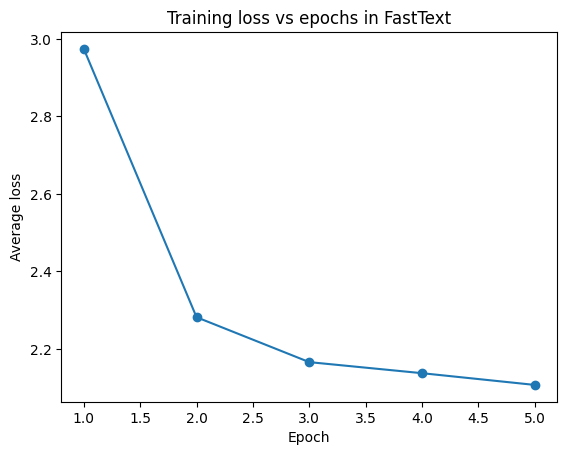

In [131]:
epoch_losses = ft.train(
    window_size=5,
    k_neg=5,
    epochs=5,
    dynamic_window=False,
    apply_subsampling=True,
    max_pairs=40_000,                  # can increase to get a smoother curve
    log_every=10_000,
)

print("epoch_losses:", epoch_losses)

# Plot loss vs epoch
plt.figure()
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.title("Training loss vs epochs in FastText")
plt.show()

In [132]:
# Save the model
MODEL_PATH = DATA_PATH / "saved_params.pt"
ft.save(MODEL_PATH)
print("saved:", MODEL_PATH.exists(), MODEL_PATH)

saved: True c:\Users\rishi\02_dev\04_python\00_projects\NLP_Course\Assignment_1\data\saved_params.pt


In [ ]:
# # inspecting the saved file
# pkg = torch.load(MODEL_PATH, map_location="cpu")
# print("Top-level keys:", pkg.keys())

# print("Z keys:", pkg["Z"].keys())
# print("V keys:", pkg["V"].keys())

# Z_w = pkg["Z"]["weight"]
# V_w = pkg["V"]["weight"]

# # see first 8 weights of the first row
# print("Z.weight[0, :8] =", Z_w[0, :8].tolist())
# print("V.weight[0, :8] =", V_w[0, :8].tolist())

# print("word vocab size:", len(pkg["id2word"]))
# print("ngram vocab size:", len(pkg["id2ngram"]))

# print("metadata:", pkg.get("metadata", None))

# # show one entry
# print("first word:", pkg["id2word"][0])
# print("first ngram:", pkg["id2ngram"][0])


# # Loading the model from the file
# ft2 = FastText.load(
#     model_path=MODEL_PATH,
#     ngram_gen=NGramGenerator(min_n=3, max_n=5),
#     trainer_cls=Trainer,
#     tokenizer=WordPieceTokenizer(),
#     corpus_path=CORPUS_PATH,
#     preprocessed_path=PREPROCESSED_PATH,
#     device="cpu",
# )

# query = ft.trainer.id2word[60]

# nns1 = ft.nearest_neighbors(query, k=10, restrict_to_top_vocab=20000)
# nns2 = ft2.nearest_neighbors(query, k=10, restrict_to_top_vocab=20000)

# print("Nearest neighbors according to original model")
# for w, s in nns1:
#     print(f"{w:25s} {s:.4f}")

# print("\nNearest neighbors according to loaded model")
# for w, s in nns2:
#     print(f"{w:25s} {s:.4f}")

In [136]:
# In vocab inference
print("\nInference of in-vocab word:")
test_word = ft.trainer.id2word[60]                          # some in-vocab word
vec = ft.get_word_vector(test_word, normalize=False)
print("test_word:", test_word)
if vec is not None:
    print("vec shape:", tuple(vec.shape))
    print("vec norm:", float(vec.norm()))
else:
    print("vec is None")

# OOV Demo
print("\nOOV word vector demo:")
ft.oov_demo("दिल्लीवालापन", k=10, restrict_to_top_vocab=20000)

# Important ngrams
print("\nImportant n-grams demo:")
out_word = "सूअर"
in_word = "बरेली"

print("Word:", in_word, "in vocab?", in_word in ft.trainer.word2id)
imp_in = ft.trainer.important_ngrams(in_word, topk=15)
for ng, score in imp_in:
    print(f"{ng:20s} {score:.4f}")

print("\nWord:", out_word, "in vocab?", out_word in ft.trainer.word2id)
imp_out = ft.trainer.important_ngrams(out_word, topk=15)
for ng, score in imp_out:
    print(f"{ng:20s} {score:.4f}")


Inference of in-vocab word:
test_word: दो
vec shape: (40,)
vec norm: 2.8699803352355957

OOV word vector demo:
OOV word: दिल्लीवालापन
In vocab? False
#known ngrams used: 29
vector shape: (40,)
vector norm: 3.75500750541687
vector (first 8): [-0.6169242262840271, -0.38817456364631653, -0.8712901473045349, -0.523053765296936, -1.300849199295044, 0.2323964685201645, -0.9090555310249329, -0.6991492509841919]
दिल्लीवालो                 0.9842
सेवन                       0.9766
ध्यान                      0.9757
यापन                       0.9753
मंज़ूर                     0.9753
ज्ञानदास                   0.9741
दिल                        0.9729
घंटे                       0.9726
तौल                        0.9725
आनंदी                      0.9723

Important n-grams demo:
Word: बरेली in vocab? True
ली>                  0.0123
<बर                  0.0051
ेली                  0.0007
रेल                  0.0005
ेली>                 0.0005
बरे                  0.0004
रेली>                0.0002
<बर